In [1]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population, compute_total_population, compute_rur_urb_pop
from imagematerials.util import merge_dims, dataset_to_array


In [2]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [3]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


In [4]:


# Rural/Urban floorspace [Time, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})

# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})



In [5]:
print(floorspace_commercial.pint.units)

meter ** 2 / person


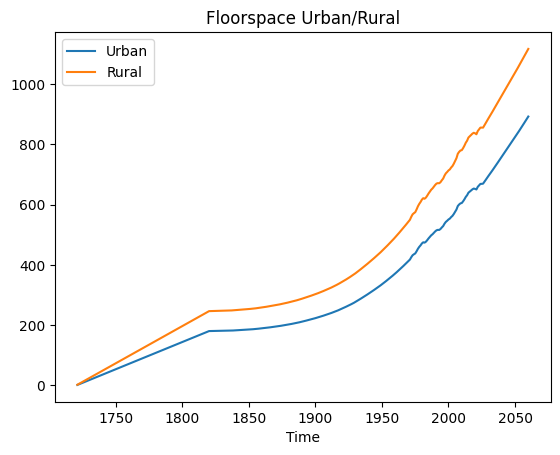

In [6]:
# Rural/Urban floorspace [Year, Region, Area]

floorspace_rururb.sel(Area="Urban", Region = '11').plot(label="Urban")
floorspace_rururb.sel(Area="Rural", Region = '11').plot(label="Rural")
floorspace_rururb.sel(Region = '11').sum(["Area"]).plot(label="total residential")
floorspace_commercial.sel(Region = '11').sum(["Type"]).plot(label="total Commercial")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [5]:
# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})

#for commercial_type in floorspace_commercial.coords["Type"].values:
#    floorspace_commercial.sum("Region").sel(Type=commercial_type).plot(label=commercial_type)
    
#plt.legend()
#plt.title("Floorspace commercial")
#plt.show()

In [6]:
from imagematerials.buildings.preprocessing.population import compute_total_population, compute_rur_urb_pop

total_pop, population_1970_future_df = compute_total_population(image_directory, base_directory)


urban_rural_pop = compute_rur_urb_pop(image_directory, population_1970_future_df)

NameError: name 'full_years' is not defined

In [ ]:
from imagematerials.buildings.constants import YEARS
from imagematerials.read_mym import read_mym_df
import pandas as pd
import xarray as xr
import numpy as np


# import total population 1971 - 2100 from IMAGE
population_1970_future_df: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "pop.scn"))
# drop empty and global region
population_1970_future_df = population_1970_future_df.loc[:, :26]

                    

population_1970_future_df: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "pop.scn"))
population_1970_future_df = population_1970_future_df.loc[:, :26]

# later: copy from here:
# repairing this function: def compute_rurpop_share(image_directory):

#rural population total meaning [Million]: the total of people living in rural areas (over time, by region)
rural_population: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "RURPOPTOT.out"))

#urban population total meaning [Million]: the total of people living in urban areas (over time, by region)
urban_population: pd.DataFrame = read_mym_df(image_directory.joinpath("Socioeconomic", "URBPOPTOT.out"))

# remove emty and global region
rural_population = rural_population.loc[:, :26]
urban_population = urban_population.loc[:, :26]

# calculate shares of urban and rural
share_rural = rural_population.sum(axis = 1)/population_1970_future_df.sum(axis = 1)*100
share_urban = urban_population.sum(axis = 1)/population_1970_future_df.sum(axis = 1)*100

# extrapolate to history:
# Calculate each region's share of global population in the base year
regional_shares = population_1970_future_df.loc[1971]/population_1970_future_df.loc[1971].sum()


# Calculate total population for 1971 and regional shares
regional_pop_1971 = population_1970_future_df.loc[1971]
regional_shares = regional_pop_1971 / regional_pop_1971.sum()

# Urban share in 1971 per region (percent)
urban_share_1971 = (urban_population.loc[1971] / regional_pop_1971) * 100


# Given global populations
global_pop_1700 = 679 # [million] https://www.johnstonsarchive.net/other/worldpop.html
global_pop_1820 = 1_033.538 # [million] https://www.rug.nl/ggdc/historicaldevelopment/maddison/releases/maddison-project-database-2020
known_years = [1700, 1820, 1971]

# Urban share in 1971 per region (percent)
urban_share_1971 = (urban_population.loc[1971] / regional_pop_1971) * 100

# Urban share known values for each region
urban_share_known = pd.DataFrame(index=known_years, columns=regional_shares.index)

for region in regional_shares.index:
    urban_share_known.loc[1700, region] = 0.0
    urban_share_known.loc[1820, region] = 7.2 #https://www2.census.gov/programs-surveys/decennial/1990/tables/cph-2/table-4.pdf
    urban_share_known.loc[1971, region] = urban_share_1971[region]

# Total global population known values
total_global_pop_known = pd.Series(data=[global_pop_1700, global_pop_1820, regional_pop_1971.sum()], index=known_years)

# Create a full range of years
full_years = np.arange(1700, 1972)

# Interpolate urban share for all years and regions
urban_share_interp = pd.DataFrame(index=full_years, columns=regional_shares.index, dtype=float)

urban_share_known = urban_share_known.astype(float)
for region in regional_shares.index:
    urban_share_interp[region] = np.interp(full_years, known_years, urban_share_known[region])

# Calculate rural share = 100 - urban share
rural_share_interp = 100 - urban_share_interp

# Interpolate total global population for all years
total_global_pop_interp = np.interp(full_years, known_years, total_global_pop_known)

# Calculate total population per region for all years by scaling with constant regional shares
total_pop_interp = pd.DataFrame(index=full_years, columns=regional_shares.index, dtype=float)
for year_idx, year in enumerate(full_years):
    total_pop_interp.loc[year] = regional_shares * total_global_pop_interp[year_idx]

# Calculate urban and rural populations per region and year
urban_pop_interp = total_pop_interp * (urban_share_interp / 100)
rural_pop_interp = total_pop_interp * (rural_share_interp / 100)


In [ ]:
urban_pop_interp

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
1700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1701,0.002377,0.022033,0.005635,0.004785,0.010725,0.010717,0.007879,0.015759,0.009559,0.002501,...,0.007588,0.061895,0.005285,0.093840,0.018335,0.013128,0.011596,0.001884,0.018040,0.005027
1702,0.004774,0.044258,0.011320,0.009612,0.021543,0.021527,0.015827,0.031655,0.019200,0.005024,...,0.015241,0.124327,0.010616,0.188494,0.036829,0.026370,0.023293,0.003784,0.036237,0.010098
1703,0.007192,0.066673,0.017053,0.014480,0.032453,0.032429,0.023843,0.047687,0.028925,0.007568,...,0.022961,0.187295,0.015992,0.283960,0.055482,0.039725,0.035090,0.005700,0.054590,0.015212
1704,0.009631,0.089279,0.022835,0.019389,0.043457,0.043425,0.031927,0.063856,0.038732,0.010134,...,0.030746,0.250799,0.021415,0.380240,0.074294,0.053194,0.046987,0.007633,0.073100,0.020369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967,15.850230,142.993277,29.713398,18.283211,53.828191,60.722905,28.390211,32.266372,9.869077,10.569621,...,31.072544,110.317615,21.506626,148.498015,40.321189,20.255897,55.185994,13.321604,24.654717,5.479592
1968,16.025687,144.573541,30.037071,18.476516,54.412257,61.387926,28.688379,32.575002,9.942410,10.682551,...,31.403489,111.337179,21.735540,149.823663,40.712902,20.435266,55.782123,13.469575,24.863873,5.521555
1969,16.202098,146.162382,30.362481,18.670832,54.999448,62.056530,28.988098,32.885100,10.015987,10.796078,...,31.736177,112.361415,21.965659,151.155144,41.106508,20.615416,56.381429,13.618354,25.073890,5.563665
1970,16.379462,147.759802,30.689627,18.866160,55.589762,62.728718,29.289369,33.196666,10.089807,10.910201,...,32.070607,113.390322,22.196982,152.492456,41.502007,20.796347,56.983911,13.767939,25.284769,5.605922


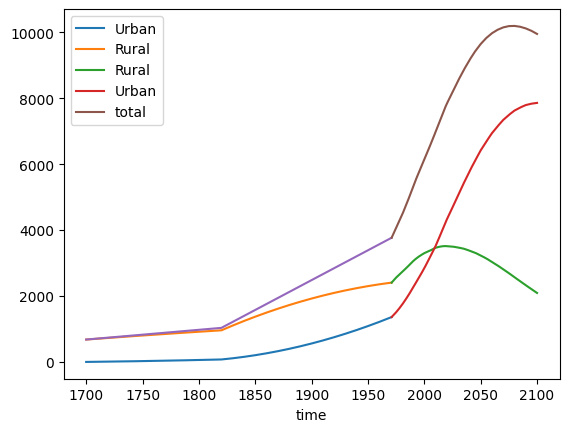

In [ ]:
urban_pop_interp.sum(axis = 1).plot(label = 'Urban')
rural_pop_interp.sum(axis = 1).plot(label = 'Rural')
rural_population.sum(axis = 1).plot(label = 'Rural')
urban_population.sum(axis = 1).plot(label = 'Urban')
total = (rural_pop_interp.sum(axis = 1) + urban_pop_interp.sum(axis = 1)).plot()
population_1970_future_df.sum(axis = 1).plot(label = 'total')

plt.legend()


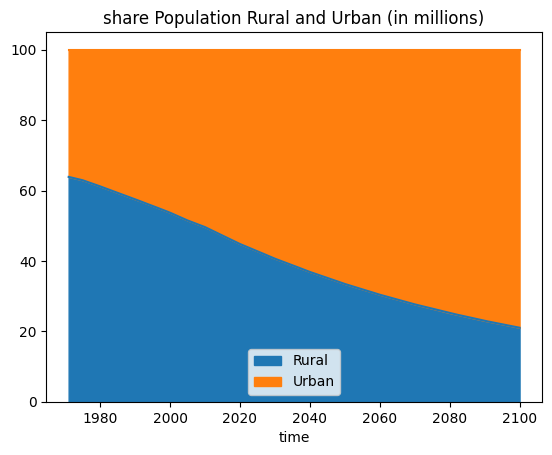

In [ ]:
df = pd.DataFrame({
    'Rural': share_rural,
    'Urban': share_urban
})

# Create stacked area plot
df.plot.area(stacked=True)

plt.title("share Population Rural and Urban (in millions)")
plt.legend()


In [ ]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\raw\\image\\SSP2_CP\\rurpop.csv'

In [ ]:
# Calculate population ("Total", "Rural", "Urban")
urban_pop_total, rural_pop_total = compute_rur_urb_pop(image_directory, base_directory)
population = compute_population(image_directory, base_directory)

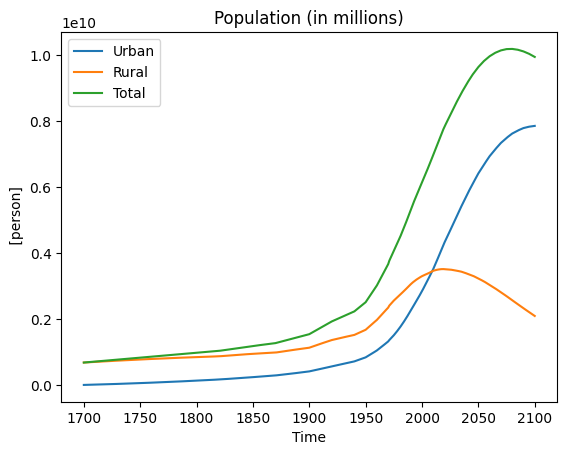

In [ ]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

In [9]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)
print('average_m2_capita:', average_m2_capita.pint.units)
housing_type = compute_housing_type(database_directory)



average_m2_capita: meter ** 2 / person


In [12]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb, None)

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials\Lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


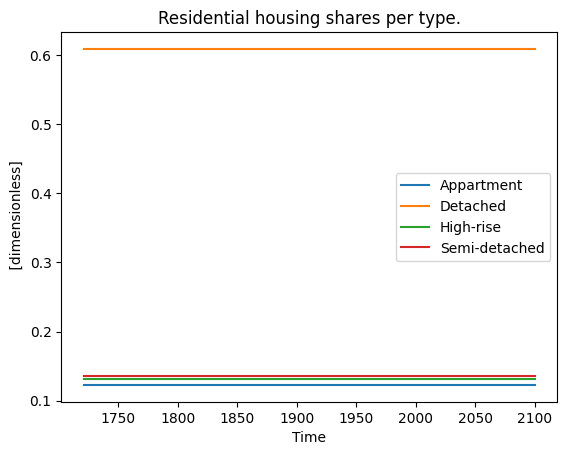

In [13]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

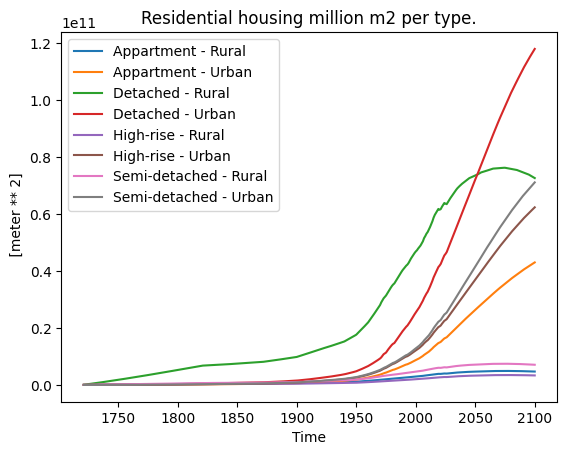

In [ ]:


for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [ ]:

floorspace = xr.concat((floorspace_residential, floorspace_commercial), dim="Type")

In [ ]:
# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = compute_lifetimes(base_directory, floorspace_commercial.coords["Type"].values)

['Appartment', 'Detached', 'High-rise', 'Semi-detached']


In [ ]:
lifetimes["weibull"].coords["Type"]

<xarray.DataArray 'Type' (Type: 12)> Size: 96B
array(['Office', 'Retail+', 'Hotels+', 'Govt+', 'Appartment - Rural',
       'Appartment - Urban', 'Detached - Rural', 'Detached - Urban',
       'High-rise - Rural', 'High-rise - Urban', 'Semi-detached - Rural',
       'Semi-detached - Urban'], dtype=object)
Coordinates:
  * Type     (Type) object 96B 'Office' 'Retail+' ... 'Semi-detached - Urban'

In [ ]:
floorspace_commercial_total = floorspace_commercial * population.sel({"Area": "Total"})
floorspace = xr.concat((floorspace_residential, floorspace_commercial_total), dim="Type")